# Assignment III: Ex-Post ML Techniques for Portfolio Optimization
## Ledoit-Wolf Shrinkage & Hierarchical Risk Parity (HRP)

**Universe:** 12 NSE stocks | **Period:** 5 years (4 train + 1 test)

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform
from scipy.optimize import minimize
from sklearn.covariance import LedoitWolf
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family': 'serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 120
})

## 1. Data Collection & Partitioning

In [2]:
TICKERS = [
    'TCS.NS', 'INFY.NS', 'HCLTECH.NS',
    'TATASTEEL.NS', 'HINDALCO.NS', 'JINDALSTEL.NS',
    'HDFCBANK.NS', 'ICICIBANK.NS', 'KOTAKBANK.NS',
    'HINDUNILVR.NS', 'ITC.NS', 'NESTLEIND.NS'
]

TICKER_LABELS = {
    'TCS.NS': 'TCS', 'INFY.NS': 'INFY', 'HCLTECH.NS': 'HCLT',
    'TATASTEEL.NS': 'TATA', 'HINDALCO.NS': 'HNDL', 'JINDALSTEL.NS': 'JNDL',
    'HDFCBANK.NS': 'HDFC', 'ICICIBANK.NS': 'ICIC', 'KOTAKBANK.NS': 'KTKB',
    'HINDUNILVR.NS': 'HUVR', 'ITC.NS': 'ITC', 'NESTLEIND.NS': 'NEST'
}

# Fetch 5 years of daily data
raw = yf.download(TICKERS, period='5y', auto_adjust=True)['Close']
raw.columns = [TICKER_LABELS[t] for t in raw.columns]
raw.dropna(how='all', inplace=True)
raw.ffill(inplace=True)

print(f"Data range: {raw.index[0].date()} to {raw.index[-1].date()}")
print(f"Total trading days: {len(raw)}")

[*********************100%***********************]  12 of 12 completed

Data range: 2021-03-01 to 2026-02-27
Total trading days: 1237


In [3]:
# --- Monthly returns (Part 1) ---
monthly_prices = raw.resample('ME').last()
monthly_returns = monthly_prices.pct_change().dropna()

# Train/test split: first 4 years train, last 1 year test
cutoff_monthly = monthly_returns.index[-12]  # last 12 months = Year 5
train_monthly = monthly_returns[monthly_returns.index < cutoff_monthly]
test_monthly  = monthly_returns[monthly_returns.index >= cutoff_monthly]

# --- Daily returns (Part 2) ---
daily_returns = raw.pct_change().dropna()
cutoff_daily = daily_returns.index[-252]
train_daily = daily_returns[daily_returns.index < cutoff_daily]
test_daily  = daily_returns[daily_returns.index >= cutoff_daily]

print(f"Monthly train: {len(train_monthly)} months | test: {len(test_monthly)} months")
print(f"Daily   train: {len(train_daily)} days   | test: {len(test_daily)} days")

Monthly train: 47 months | test: 12 months
Daily   train: 984 days   | test: 252 days


---
## Part 1: Statistical Regularization via Ledoit-Wolf Shrinkage

### Task 1.1: The Ill-Conditioned Sample Covariance Matrix

In [4]:
# ---- Sample Covariance & Condition Number ----
S = train_monthly.cov().values * 12          # annualised
labels = list(train_monthly.columns)

eigenvalues = np.linalg.eigvalsh(S)
kappa = eigenvalues.max() / eigenvalues.min()  # condition number

print("Sample Covariance Matrix (annualised, monthly)")
print(pd.DataFrame(S, index=labels, columns=labels).round(6).to_string())
print(f"\nMax eigenvalue : {eigenvalues.max():.6f}")
print(f"Min eigenvalue : {eigenvalues.min():.6f}")
print(f"Condition number κ = {kappa:.2f}")
print(f"\nInterpretation: κ >> 1 (threshold ~30) confirms the matrix is ill-conditioned.")
print(f"A κ of {kappa:.0f} means small errors in returns get amplified ~{kappa:.0f}x in the solution.")

Sample Covariance Matrix (annualised, monthly)
          HCLT      HDFC      HNDL      HUVR      ICIC      INFY       ITC      JNDL      KTKB      NEST      TATA       TCS
HCLT  0.064630  0.006820  0.010017  0.020194 -0.000210  0.043559  0.012405 -0.005605  0.003048  0.015601  0.002378  0.035910
HDFC  0.006820  0.030510  0.026621  0.013084  0.012650  0.004306  0.010289  0.011997  0.014356  0.015152  0.013773  0.010701
HNDL  0.010017  0.026621  0.124168  0.011993  0.026722  0.010179  0.006294  0.084696  0.019549  0.016829  0.089397  0.007375
HUVR  0.020194  0.013084  0.011993  0.052791  0.007989  0.017721  0.015702 -0.012565  0.015770  0.024105  0.009681  0.024892
ICIC -0.000210  0.012650  0.026722  0.007989  0.035726  0.004398  0.008010  0.020695  0.015297  0.012207  0.027411  0.004070
INFY  0.043559  0.004306  0.010179  0.017721  0.004398  0.061145  0.008026  0.003903 -0.004163  0.004486  0.011455  0.036376
ITC   0.012405  0.010289  0.006294  0.015702  0.008010  0.008026  0.041467  0.

### Task 1.1b: Bootstrap Resampling – Demonstrating Instability

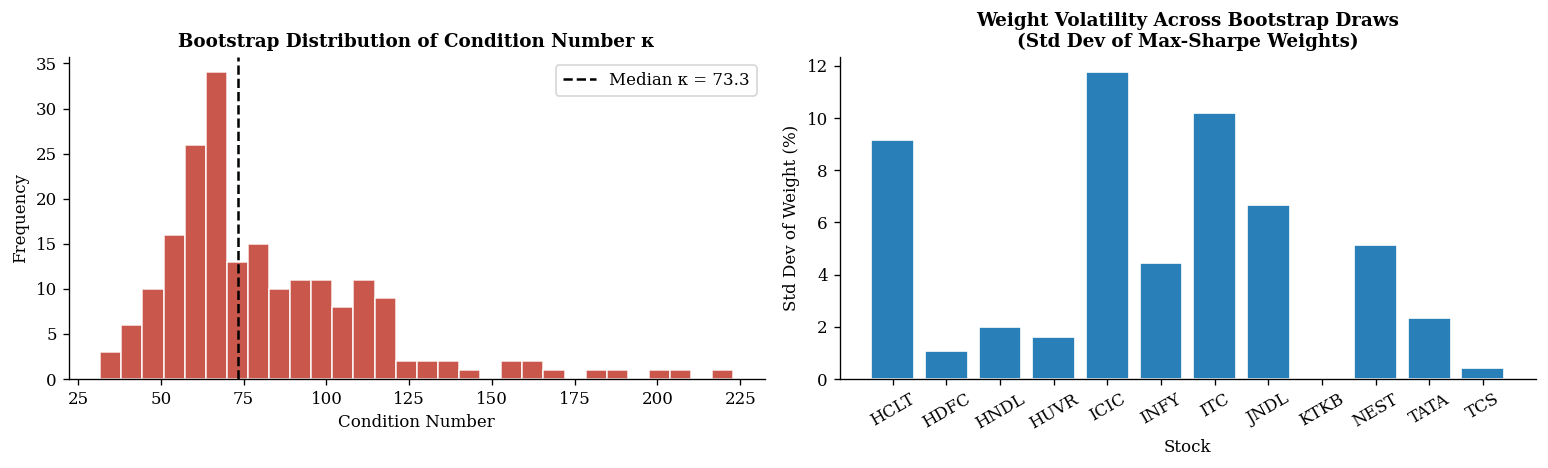

Average weight std dev: 4.6% — large swings confirm the ill-conditioning problem.


In [6]:
np.random.seed(42)
N_BOOTSTRAP = 200
N_ASSETS = len(labels)
n_obs = len(train_monthly)

bootstrap_weights = []
bootstrap_kappas  = []

def portfolio_sharpe_neg(w, mu, cov):
    """Negative Sharpe for minimization (rf = 0 for simplicity)."""
    ret = w @ mu
    vol = np.sqrt(w @ cov @ w)
    return -ret / vol

def max_sharpe_weights(mu, cov):
    n = len(mu)
    constraints = [{'type': 'eq', 'fun': lambda w: w.sum() - 1}]
    bounds = [(0, 1)] * n
    w0 = np.ones(n) / n
    res = minimize(portfolio_sharpe_neg, w0, args=(mu, cov),
                   method='SLSQP', bounds=bounds, constraints=constraints,
                   options={'ftol': 1e-9, 'maxiter': 1000})
    return res.x if res.success else w0

mu_train = train_monthly.mean().values * 12

for _ in range(N_BOOTSTRAP):
    idx = np.random.choice(n_obs, n_obs, replace=True)
    sample = train_monthly.iloc[idx].values
    S_b = np.cov(sample.T) * 12
    eigs = np.linalg.eigvalsh(S_b)
    bootstrap_kappas.append(eigs.max() / max(eigs.min(), 1e-10))
    try:
        w = max_sharpe_weights(mu_train, S_b)
    except:
        w = np.ones(N_ASSETS) / N_ASSETS
    bootstrap_weights.append(w)

bootstrap_weights = np.array(bootstrap_weights)
weight_std = bootstrap_weights.std(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(bootstrap_kappas, bins=30, color='#c0392b', edgecolor='white', alpha=0.85)
axes[0].set_title('Bootstrap Distribution of Condition Number κ', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Condition Number')
axes[0].set_ylabel('Frequency')
axes[0].axvline(np.median(bootstrap_kappas), color='black', linestyle='--',
                label=f'Median κ = {np.median(bootstrap_kappas):.1f}')
axes[0].legend()

axes[1].bar(labels, weight_std * 100, color='#2980b9', edgecolor='white')
axes[1].set_title('Weight Volatility Across Bootstrap Draws\n(Std Dev of Max-Sharpe Weights)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Stock')
axes[1].set_ylabel('Std Dev of Weight (%)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('fig_bootstrap_instability.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Average weight std dev: {weight_std.mean()*100:.1f}% — large swings confirm the ill-conditioning problem.")

### Task 1.2: Ledoit-Wolf Shrinkage Implementation

In [8]:
# ---- Ledoit-Wolf analytical estimator (Oracle approximating shrinkage) ----
#
# The Ledoit-Wolf estimator shrinks S toward a structured target F:
#   Σ_LW = (1 - α) * S + α * F
# where F = (mean_diag(S)) * I  (scaled identity — minimum-information prior),
# and α is derived analytically to minimise E[||Σ_LW - Σ_true||²_F].
#
# We use sklearn's Oracle Approximating Shrinkage (OAS) variant here.

lw = LedoitWolf().fit(train_monthly.values)
alpha = lw.shrinkage_          # shrinkage intensity
S_shrunk = lw.covariance_ * 12 # annualised

# Condition number comparison
eigs_lw = np.linalg.eigvalsh(S_shrunk)
kappa_lw = eigs_lw.max() / eigs_lw.min()

print(f"Ledoit-Wolf shrinkage intensity α = {alpha:.4f}")
print(f"  => {alpha*100:.1f}% weight on structured target (scaled identity)")
print(f"  => {(1-alpha)*100:.1f}% weight retained on sample matrix")
print(f"\nCondition number — Sample: {kappa:.1f}  |  Shrunk: {kappa_lw:.1f}")
print(f"Condition number reduced by {(1 - kappa_lw/kappa)*100:.1f}%")

Ledoit-Wolf shrinkage intensity α = 0.1698
  => 17.0% weight on structured target (scaled identity)
  => 83.0% weight retained on sample matrix

Condition number — Sample: 35.6  |  Shrunk: 15.0
Condition number reduced by 58.0%


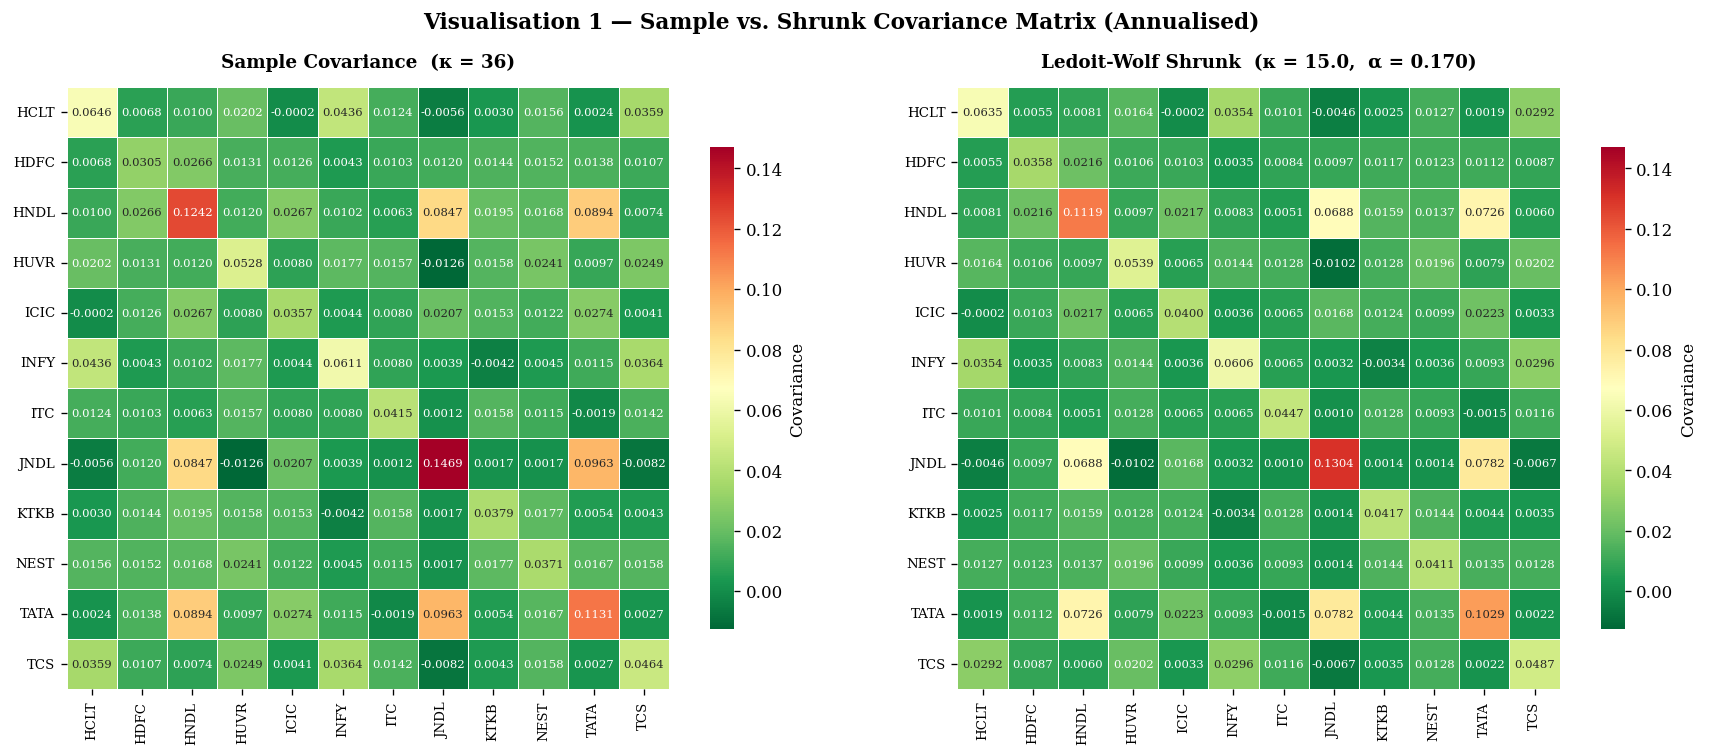

In [9]:
# --- Visualisation 1: Side-by-side Heatmap ---

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

vmin = min(S.min(), S_shrunk.min())
vmax = max(S.max(), S_shrunk.max())

for ax, mat, title in zip(axes,
                           [S, S_shrunk],
                           [f'Sample Covariance  (κ = {kappa:.0f})',
                            f'Ledoit-Wolf Shrunk  (κ = {kappa_lw:.1f},  α = {alpha:.3f})']):
    sns.heatmap(pd.DataFrame(mat, index=labels, columns=labels),
                ax=ax, cmap='RdYlGn_r', vmin=vmin, vmax=vmax,
                annot=True, fmt='.4f', annot_kws={'size': 7},
                linewidths=0.3, square=True,
                cbar_kws={'shrink': 0.8, 'label': 'Covariance'})
    ax.set_title(title, fontsize=11, fontweight='bold', pad=12)
    ax.tick_params(labelsize=8)

fig.suptitle('Visualisation 1 — Sample vs. Shrunk Covariance Matrix (Annualised)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_covariance_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# --- Max-Sharpe weights: Sample vs. Shrunk ---
mu = train_monthly.mean().values * 12

w_sample = max_sharpe_weights(mu, S)
w_shrunk = max_sharpe_weights(mu, S_shrunk)

weight_df = pd.DataFrame({'Sample Cov': w_sample, 'Ledoit-Wolf': w_shrunk},
                          index=labels)
print("Max-Sharpe Portfolio Weights (%)")
print((weight_df * 100).round(2).to_string())

turnover = np.abs(w_shrunk - w_sample).sum()
print(f"\nTotal turnover (Sample → LW): {turnover*100:.1f}%")

Max-Sharpe Portfolio Weights (%)
      Sample Cov  Ledoit-Wolf
HCLT       20.39        21.47
HDFC        0.00         0.00
HNDL        0.00         0.00
HUVR        0.00         0.00
ICIC       34.39        31.33
INFY        0.00         0.00
ITC        31.87        31.20
JNDL       13.35        16.01
KTKB        0.00         0.00
NEST        0.00         0.00
TATA        0.00         0.00
TCS         0.00         0.00

Total turnover (Sample → LW): 7.5%


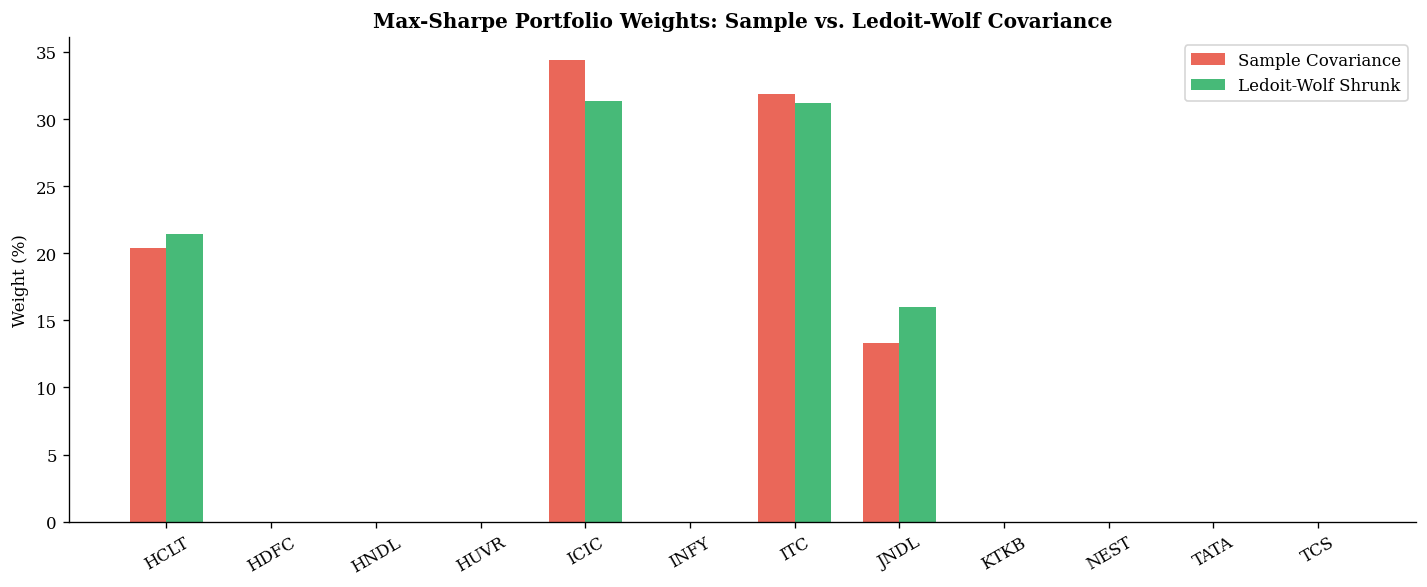

In [12]:
# Weight comparison bar chart
x = np.arange(len(labels))
width = 0.35
fig, ax = plt.subplots(figsize=(12, 5))

ax.bar(x - width/2, w_sample * 100, width, label='Sample Covariance', color='#e74c3c', alpha=0.85)
ax.bar(x + width/2, w_shrunk * 100, width, label='Ledoit-Wolf Shrunk', color='#27ae60', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=30)
ax.set_ylabel('Weight (%)')
ax.set_title('Max-Sharpe Portfolio Weights: Sample vs. Ledoit-Wolf Covariance', fontweight='bold')
ax.legend()
ax.axhline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.savefig('fig_weights_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Part 2: Structural Regularization via Hierarchical Risk Parity (HRP)

### Step 1: Distance matrix & linkage

In [13]:
# Use daily returns for Part 2
corr = train_daily.corr()
cov_daily = train_daily.cov() * 252    # annualised daily covariance
labels_d = list(corr.columns)

# Convert correlation to distance matrix  d(i,j) = sqrt(0.5*(1-ρ))
# This maps ρ=1 → d=0, ρ=-1 → d=1, is a proper metric.
dist_matrix = np.sqrt(0.5 * (1 - corr.values))
np.fill_diagonal(dist_matrix, 0)

# Condensed distance vector for scipy
condensed = squareform(dist_matrix)

# Agglomerative clustering with single-linkage
link = linkage(condensed, method='single')

print("Correlation matrix shape:", corr.shape)
print("Linkage matrix shape:", link.shape)

Correlation matrix shape: (12, 12)
Linkage matrix shape: (11, 4)


### Visualisation 2: HRP Dendrogram

In [14]:
# Identify clusters at a cut threshold and label them
threshold = 0.30
cluster_ids = fcluster(link, threshold, criterion='distance')

CLUSTER_LABELS = {}
for i, (ticker, cid) in enumerate(zip(labels_d, cluster_ids)):
    CLUSTER_LABELS[ticker] = cid

unique_clusters = np.unique(cluster_ids)
cluster_names = {}
for cid in unique_clusters:
    members = [t for t, c in zip(labels_d, cluster_ids) if c == cid]
    cluster_names[cid] = members

print("Discovered clusters (threshold = {:.2f})".format(threshold))
for cid, members in cluster_names.items():
    print(f"  Cluster {cid}: {members}")

Discovered clusters (threshold = 0.30)
  Cluster 1: ['HUVR']
  Cluster 2: ['NEST']
  Cluster 3: ['ITC']
  Cluster 4: ['INFY']
  Cluster 5: ['TCS']
  Cluster 6: ['HCLT']
  Cluster 7: ['JNDL']
  Cluster 8: ['TATA']
  Cluster 9: ['HNDL']
  Cluster 10: ['HDFC']
  Cluster 11: ['ICIC']
  Cluster 12: ['KTKB']


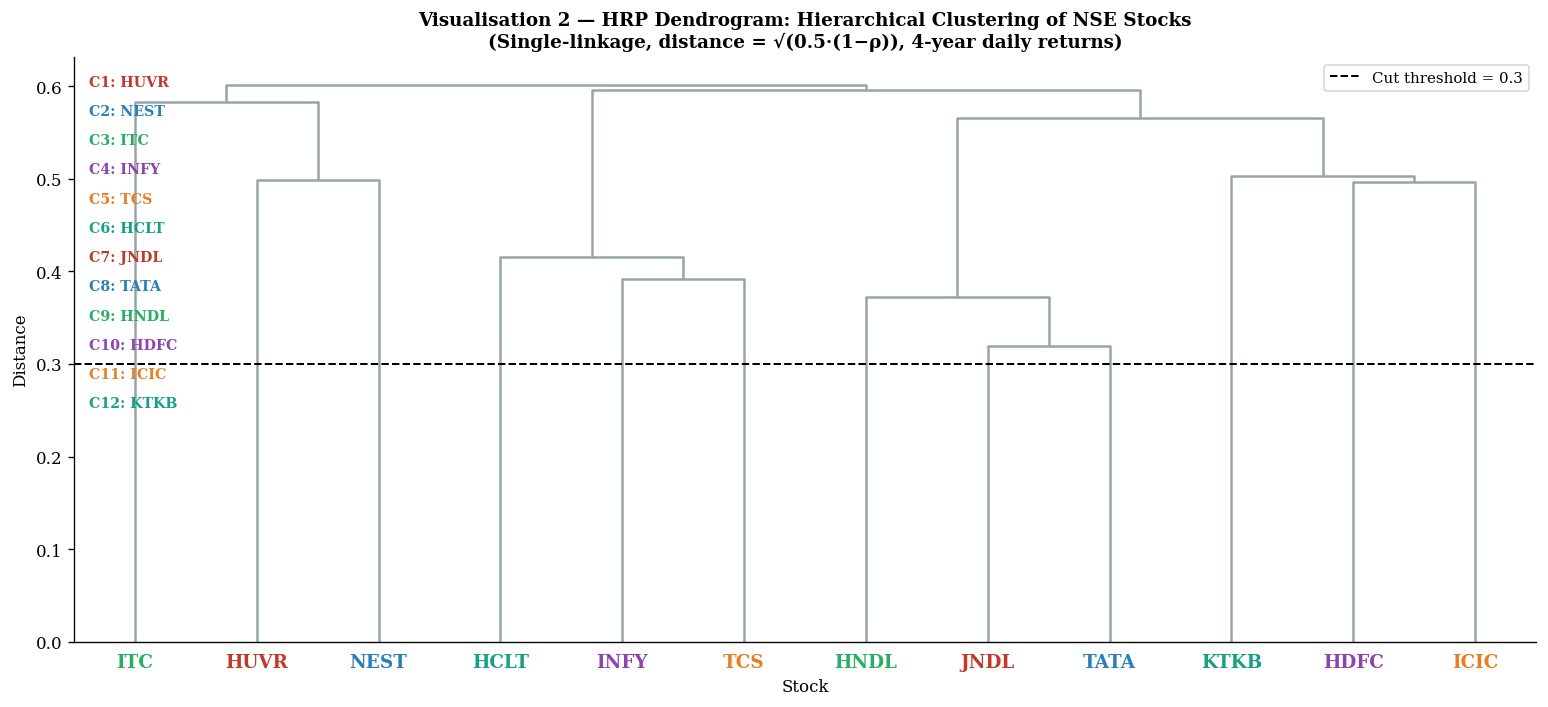

In [15]:
PALETTE = ['#c0392b', '#2980b9', '#27ae60', '#8e44ad', '#e67e22', '#16a085']

# Assign a colour per cluster for the dendrogram labels
id_to_colour = {cid: PALETTE[i % len(PALETTE)] for i, cid in enumerate(unique_clusters)}

def leaf_colours(id_list):
    colours = []
    for leaf in id_list:
        ticker = labels_d[leaf]
        cid = CLUSTER_LABELS[ticker]
        colours.append(id_to_colour[cid])
    return colours

fig, ax = plt.subplots(figsize=(13, 6))

dend = dendrogram(
    link,
    labels=labels_d,
    ax=ax,
    above_threshold_color='#95a5a6',
    color_threshold=threshold,
    leaf_rotation=0,
    leaf_font_size=11,
)

# Colour leaf labels by cluster
for lbl_obj, leaf in zip(ax.get_xticklabels(), dend['leaves']):
    ticker = labels_d[leaf]
    cid = CLUSTER_LABELS[ticker]
    lbl_obj.set_color(id_to_colour[cid])
    lbl_obj.set_fontweight('bold')

ax.axhline(threshold, color='black', linestyle='--', linewidth=1.2,
           label=f'Cut threshold = {threshold}')

# Annotate clusters
for cid, members in cluster_names.items():
    label = f'C{cid}: {" · ".join(members)}'
    ax.text(0.01, 0.97 - (cid-1)*0.05, label,
            transform=ax.transAxes, color=id_to_colour[cid],
            fontsize=8.5, va='top', fontweight='bold')

ax.set_title('Visualisation 2 — HRP Dendrogram: Hierarchical Clustering of NSE Stocks\n'
             '(Single-linkage, distance = √(0.5·(1−ρ)), 4-year daily returns)',
             fontsize=11, fontweight='bold')
ax.set_xlabel('Stock', fontsize=10)
ax.set_ylabel('Distance', fontsize=10)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('fig_hrp_dendrogram.png', dpi=150, bbox_inches='tight')
plt.show()

### Step 2: Quasi-Diagonalisation & Recursive Bisection

In [16]:
def get_quasi_diag(link_mat):
    """Reorder assets so that similar assets are adjacent (quasi-diagonalisation).
    Uses scipy leaves_list — equivalent to Lopez de Prado Algorithm 2 but
    avoids pandas RangeIndex fragility from repeated pd.concat + reset_index."""
    from scipy.cluster.hierarchy import leaves_list
    return leaves_list(link_mat).tolist()


def _cluster_var(cov_df, items):
    """Inv-variance portfolio variance for a sub-cluster (top-level to avoid closure bugs)."""
    cov_sub = cov_df.loc[items, items].values
    inv_var = 1.0 / np.maximum(np.diag(cov_sub), 1e-10)
    w_sub = inv_var / inv_var.sum()
    return float(w_sub @ cov_sub @ w_sub)


def bisect_recursive(cov, sorted_items):
    """Recursive bisection (Lopez de Prado 2016).
    Capital allocated proportional to complement of sub-cluster variance."""
    weights = pd.Series(1.0, index=sorted_items)
    clusters = [sorted_items]

    while clusters:
        clusters_new = []
        for cluster in clusters:
            if len(cluster) == 1:
                continue
            mid = len(cluster) // 2
            left  = cluster[:mid]
            right = cluster[mid:]

            var_left  = _cluster_var(cov, left)
            var_right = _cluster_var(cov, right)

            alpha_left  = 1.0 - var_left / (var_left + var_right)
            alpha_right = 1.0 - alpha_left

            weights[left]  *= alpha_left
            weights[right] *= alpha_right

            if len(left)  > 1: clusters_new.append(left)
            if len(right) > 1: clusters_new.append(right)
        clusters = clusters_new

    return weights


# Run HRP
sorted_idx = get_quasi_diag(link)
sorted_tickers = [labels_d[i] for i in sorted_idx]
print("Quasi-diagonal order:", sorted_tickers)

hrp_weights = bisect_recursive(cov_daily, sorted_tickers)
hrp_weights_aligned = hrp_weights[labels_d]   # align to original order

print("\nHRP Weights:")
print((hrp_weights_aligned * 100).round(2).to_string())
print(f"\nSum of weights: {hrp_weights_aligned.sum():.6f}")


Quasi-diagonal order: ['ITC', 'HUVR', 'NEST', 'HCLT', 'INFY', 'TCS', 'HNDL', 'JNDL', 'TATA', 'KTKB', 'HDFC', 'ICIC']

HRP Weights:
HCLT     9.86
HDFC     8.22
HNDL     4.18
HUVR    10.96
ICIC     8.15
INFY     5.78
ITC     16.48
JNDL     2.00
KTKB    10.79
NEST    13.45
TATA     2.59
TCS      7.56

Sum of weights: 1.000000


### MPT (Minimum Variance) vs HRP: Turnover Analysis

In [17]:
def min_variance_weights(cov_mat):
    """Standard MPT minimum-variance portfolio."""
    n = cov_mat.shape[0]
    constraints = [{'type': 'eq', 'fun': lambda w: w.sum() - 1}]
    bounds = [(0, 1)] * n
    w0 = np.ones(n) / n
    res = minimize(lambda w: w @ cov_mat @ w, w0,
                   method='SLSQP', bounds=bounds,
                   constraints=constraints,
                   options={'ftol': 1e-10})
    return res.x if res.success else w0

# Rolling window turnover comparison — simulate 12 monthly rebalances in test year
WINDOW = 252   # 1-year lookback in trading days
test_dates = test_daily.index
rebalance_dates = pd.date_range(test_dates[0], test_dates[-1], freq='ME')
rebalance_dates = [d for d in rebalance_dates if d in daily_returns.index or
                   daily_returns.index[daily_returns.index >= d][0] is not None]

hrp_weights_series  = []
mpt_weights_series  = []
date_series         = []

for rd in rebalance_dates[:12]:
    loc = daily_returns.index.searchsorted(rd)
    if loc < WINDOW:
        continue
    window_data = daily_returns.iloc[loc - WINDOW: loc]
    cov_w = window_data.cov() * 252
    corr_w = window_data.corr()
    dist_w = np.sqrt(0.5 * (1 - corr_w.values))
    np.fill_diagonal(dist_w, 0)
    link_w = linkage(squareform(dist_w), method='single')
    sorted_w = get_quasi_diag(link_w)
    sorted_t_w = [labels_d[i] for i in sorted_w]
    h_w = bisect_recursive(cov_w, sorted_t_w)
    m_w = min_variance_weights(cov_w.values)
    hrp_weights_series.append(h_w[labels_d].values)
    mpt_weights_series.append(m_w)
    date_series.append(rd)

hrp_ws = np.array(hrp_weights_series)
mpt_ws = np.array(mpt_weights_series)

hrp_turnover = np.abs(np.diff(hrp_ws, axis=0)).sum(axis=1)
mpt_turnover = np.abs(np.diff(mpt_ws, axis=0)).sum(axis=1)

print(f"HRP avg monthly turnover: {hrp_turnover.mean()*100:.1f}%")
print(f"MPT avg monthly turnover: {mpt_turnover.mean()*100:.1f}%")
print(f"Turnover reduction (HRP vs MPT): {(1 - hrp_turnover.mean()/mpt_turnover.mean())*100:.1f}%")

HRP avg monthly turnover: 8.1%
MPT avg monthly turnover: 13.9%
Turnover reduction (HRP vs MPT): 41.5%


### Visualisation 3: Weight Sensitivity — Banking Crisis Analogue

In [18]:
# We simulate a 'banking stress' scenario by perturbing correlations
# for the three banking stocks (HDFC, ICIC, KTKB) upward by 0.25 (flight-to-correlation)

BANK_STOCKS = ['HDFC', 'ICIC', 'KTKB']

corr_stressed = corr.copy()
for s1 in BANK_STOCKS:
    for s2 in BANK_STOCKS:
        if s1 != s2:
            corr_stressed.loc[s1, s2] = min(corr.loc[s1, s2] + 0.25, 0.99)

# Rebuild covariance from stressed correlation
std_devs = np.sqrt(np.diag(cov_daily.values))
cov_stressed = corr_stressed.values * np.outer(std_devs, std_devs)
cov_stressed_df = pd.DataFrame(cov_stressed, index=labels_d, columns=labels_d)

# MPT weights under normal vs stressed conditions
w_mpt_normal   = min_variance_weights(cov_daily.values)
w_mpt_stressed = min_variance_weights(cov_stressed)

# HRP weights under normal vs stressed conditions
def hrp_from_cov(cov_df):
    std = np.sqrt(np.diag(cov_df.values))
    corr_t = cov_df.values / np.outer(std, std)
    dist_t = np.sqrt(0.5 * (1 - corr_t))
    np.fill_diagonal(dist_t, 0)
    link_t = linkage(squareform(dist_t), method='single')
    sidx = get_quasi_diag(link_t)
    st = [cov_df.columns[i] for i in sidx]
    return bisect_recursive(cov_df, st)[cov_df.columns].values

w_hrp_normal   = hrp_from_cov(cov_daily)
w_hrp_stressed = hrp_from_cov(cov_stressed_df)

mpt_shift = np.abs(w_mpt_stressed - w_mpt_normal)
hrp_shift = np.abs(w_hrp_stressed - w_hrp_normal)

print("Total weight shift under banking stress:")
print(f"  MPT: {mpt_shift.sum()*100:.1f}%  vs  HRP: {hrp_shift.sum()*100:.1f}%")

Total weight shift under banking stress:
  MPT: 11.6%  vs  HRP: 6.9%


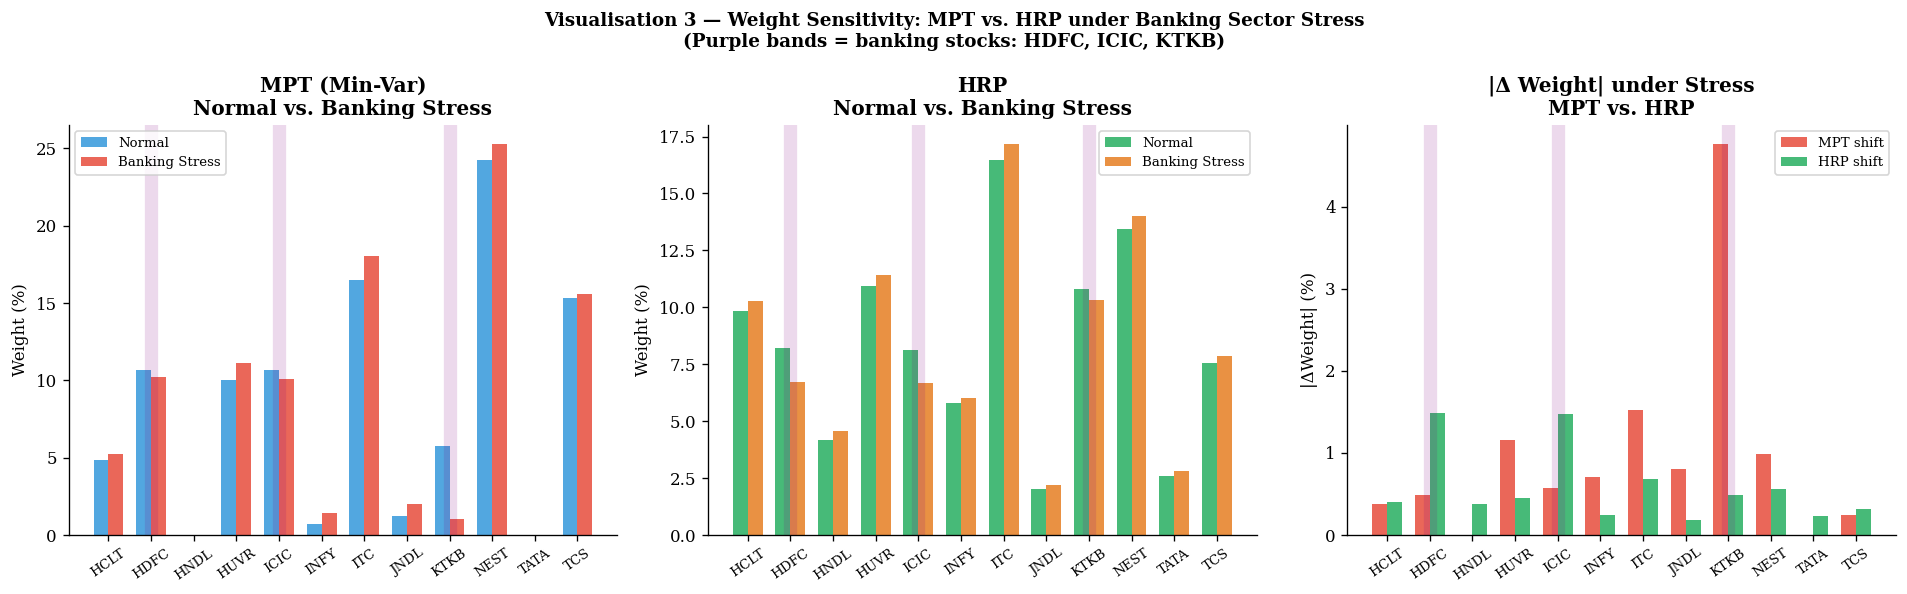

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

x = np.arange(len(labels_d))
w = 0.35

# Panel A: MPT weight shift
axes[0].bar(x - w/2, w_mpt_normal * 100, w, label='Normal', color='#3498db', alpha=0.85)
axes[0].bar(x + w/2, w_mpt_stressed * 100, w, label='Banking Stress', color='#e74c3c', alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(labels_d, rotation=35, fontsize=8)
axes[0].set_title('MPT (Min-Var)\nNormal vs. Banking Stress', fontweight='bold')
axes[0].set_ylabel('Weight (%)')
axes[0].legend(fontsize=8)

# Panel B: HRP weight shift
axes[1].bar(x - w/2, w_hrp_normal * 100, w, label='Normal', color='#27ae60', alpha=0.85)
axes[1].bar(x + w/2, w_hrp_stressed * 100, w, label='Banking Stress', color='#e67e22', alpha=0.85)
axes[1].set_xticks(x); axes[1].set_xticklabels(labels_d, rotation=35, fontsize=8)
axes[1].set_title('HRP\nNormal vs. Banking Stress', fontweight='bold')
axes[1].set_ylabel('Weight (%)')
axes[1].legend(fontsize=8)

# Panel C: Absolute weight shift comparison
axes[2].bar(x - w/2, mpt_shift * 100, w, label='MPT shift', color='#e74c3c', alpha=0.85)
axes[2].bar(x + w/2, hrp_shift * 100, w, label='HRP shift', color='#27ae60', alpha=0.85)
axes[2].set_xticks(x); axes[2].set_xticklabels(labels_d, rotation=35, fontsize=8)
axes[2].set_title('|Δ Weight| under Stress\nMPT vs. HRP', fontweight='bold')
axes[2].set_ylabel('|ΔWeight| (%)')
axes[2].legend(fontsize=8)

# Highlight bank stocks
for ax in axes:
    for i, lbl in enumerate(labels_d):
        if lbl in BANK_STOCKS:
            ax.axvline(i, color='purple', alpha=0.15, linewidth=8)

fig.suptitle('Visualisation 3 — Weight Sensitivity: MPT vs. HRP under Banking Sector Stress\n'
             '(Purple bands = banking stocks: HDFC, ICIC, KTKB)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_weight_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

### Rolling Turnover Plot: HRP vs. MPT

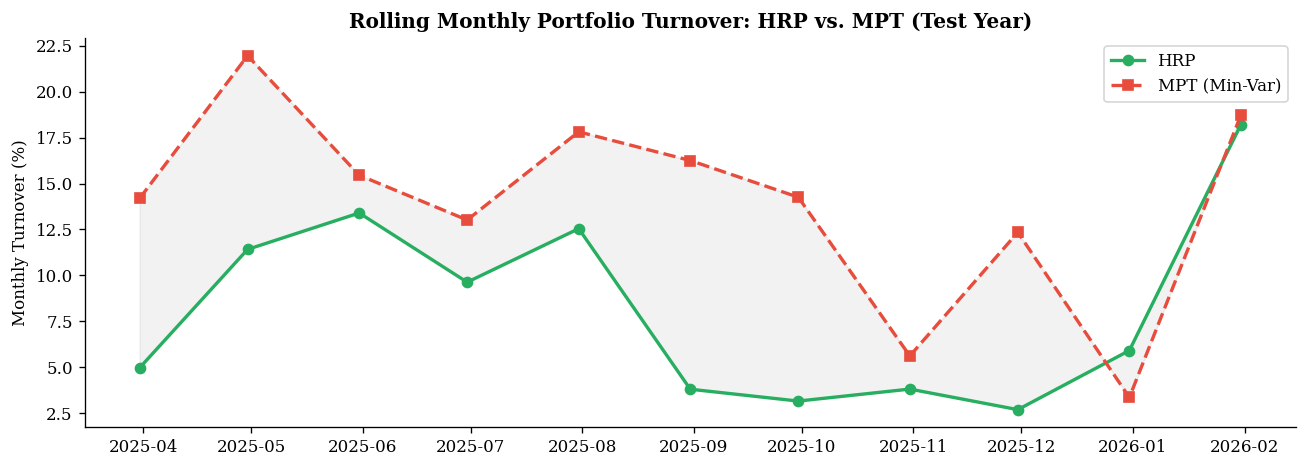

In [20]:
if len(hrp_turnover) > 0:
    rebal_plot_dates = date_series[1:1+len(hrp_turnover)]

    fig, ax = plt.subplots(figsize=(11, 4))
    ax.plot(rebal_plot_dates, hrp_turnover * 100, 'o-', color='#27ae60', label='HRP', linewidth=2)
    ax.plot(rebal_plot_dates, mpt_turnover * 100, 's--', color='#e74c3c', label='MPT (Min-Var)', linewidth=2)
    ax.fill_between(rebal_plot_dates,
                    hrp_turnover * 100, mpt_turnover * 100, alpha=0.1, color='grey')
    ax.set_ylabel('Monthly Turnover (%)')
    ax.set_title('Rolling Monthly Portfolio Turnover: HRP vs. MPT (Test Year)', fontweight='bold')
    ax.legend()
    plt.tight_layout()
    plt.savefig('fig_turnover.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("Not enough rebalancing periods for turnover plot.")

---
## Summary Statistics

In [21]:
print("="*60)
print("FINAL SUMMARY")
print("="*60)
print(f"\nPART 1 — Ledoit-Wolf Shrinkage")
print(f"  Shrinkage intensity α         : {alpha:.4f}")
print(f"  Sample matrix condition κ     : {kappa:.1f}")
print(f"  Shrunk matrix condition κ     : {kappa_lw:.1f}")
print(f"  Condition number improvement  : {(1 - kappa_lw/kappa)*100:.1f}%")

print(f"\nPART 2 — Hierarchical Risk Parity")
print(f"  HRP avg monthly turnover      : {hrp_turnover.mean()*100:.1f}%")
print(f"  MPT avg monthly turnover      : {mpt_turnover.mean()*100:.1f}%")
print(f"  Turnover reduction via HRP    : {(1 - hrp_turnover.mean()/mpt_turnover.mean())*100:.1f}%")
print(f"  Banking stress MPT shift      : {mpt_shift.sum()*100:.1f}%")
print(f"  Banking stress HRP shift      : {hrp_shift.sum()*100:.1f}%")
print("="*60)

FINAL SUMMARY

PART 1 — Ledoit-Wolf Shrinkage
  Shrinkage intensity α         : 0.1698
  Sample matrix condition κ     : 35.6
  Shrunk matrix condition κ     : 15.0
  Condition number improvement  : 58.0%

PART 2 — Hierarchical Risk Parity
  HRP avg monthly turnover      : 8.1%
  MPT avg monthly turnover      : 13.9%
  Turnover reduction via HRP    : 41.5%
  Banking stress MPT shift      : 11.6%
  Banking stress HRP shift      : 6.9%
